In [2]:
import pandas as pd

# Create the dataset
data = {
    'Hours': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Score': [35, 45, 48, 52, 60, 68, 75, 82, 88, 95]
}

df = pd.DataFrame(data)
print("Dataset created successfully!")
print(df)

Dataset created successfully!
   Hours  Score
0      1     35
1      2     45
2      3     48
3      4     52
4      5     60
5      6     68
6      7     75
7      8     82
8      9     88
9     10     95


In [3]:
from sklearn.model_selection import train_test_split

# X = input feature (Hours), y = output/target (Score)
X = df[['Hours']]  # double brackets → gives a DataFrame, not a Series
y = df['Score']

# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 8
Testing samples: 2


In [4]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print(f"Slope (coefficient): {model.coef_[0]:.2f}")
print(f"Intercept: {model.intercept_:.2f}")

Slope (coefficient): 6.78
Intercept: 27.06


In [5]:
y_pred = model.predict(X_test)

print("\nActual vs Predicted:")
for actual, predicted in zip(y_test, y_pred):
    print(f"Actual: {actual}, Predicted: {predicted:.2f}")


Actual vs Predicted:
Actual: 88, Predicted: 88.12
Actual: 45, Predicted: 40.63


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


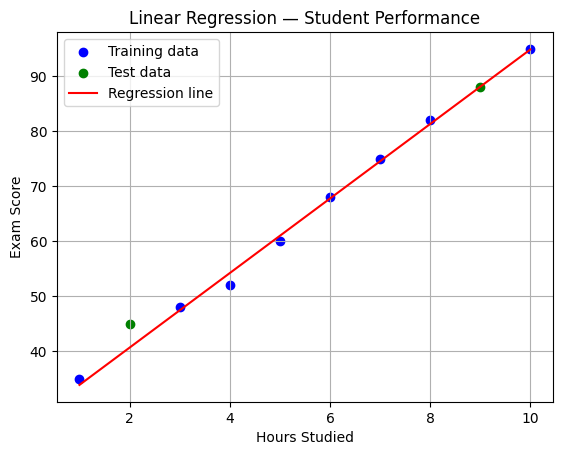

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# Plot training data points
plt.scatter(X_train, y_train, color='blue', label='Training data')

# Plot test data points
plt.scatter(X_test, y_test, color='green', label='Test data')

# Plot regression line
x_line = np.linspace(1, 10, 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color='red', label='Regression line')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Linear Regression — Student Performance')
plt.legend()
plt.grid(True)
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error

# Predict on test data
y_pred = model.predict(X_test)

# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print(f"Mean Absolute Error: {mae:.2f} points")

Mean Absolute Error: 2.25 points


In [8]:
import pandas as pd

results = pd.DataFrame({
    'Actual Score': y_test.values,
    'Predicted Score': y_pred.round(2),
    'Difference': (y_test.values - y_pred).round(2)
})

print(results.to_string(index=False))

 Actual Score  Predicted Score  Difference
           88            88.12       -0.12
           45            40.63        4.37


In [9]:
# Predict score for a student who studied 4.5 hours
new_hours = [[4.5]]
predicted_score = model.predict(new_hours)
print(f"Predicted score for 4.5 hours of study: {predicted_score[0]:.2f}")

# Try a few more for good measure
for hours in [2.0, 6.0, 9.5]:
    score = model.predict([[hours]])
    print(f"Hours: {hours} → Predicted Score: {score[0]:.2f}")

Predicted score for 4.5 hours of study: 57.59
Hours: 2.0 → Predicted Score: 40.63
Hours: 6.0 → Predicted Score: 67.77
Hours: 9.5 → Predicted Score: 91.51


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


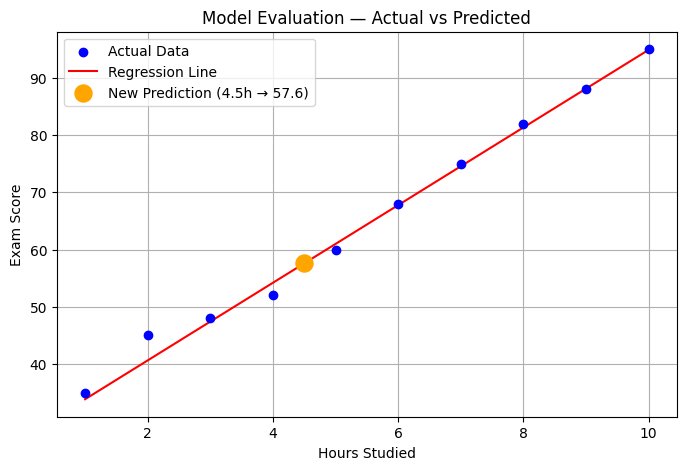

In [10]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 5))

# All data points
plt.scatter(df['Hours'], df['Score'], color='blue', label='Actual Data', zorder=5)

# Regression line
x_line = np.linspace(1, 10, 100).reshape(-1, 1)
plt.plot(x_line, model.predict(x_line), color='red', label='Regression Line')

# Highlight the new prediction (4.5 hours)
plt.scatter([[4.5]], [predicted_score[0]], color='orange',
            s=150, zorder=6, label=f'New Prediction (4.5h → {predicted_score[0]:.1f})')

plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.title('Model Evaluation — Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
print("=" * 40)
print("      MODEL EVALUATION SUMMARY")
print("=" * 40)
print(f"  Training samples     : {len(X_train)}")
print(f"  Testing samples      : {len(X_test)}")
print(f"  Slope (coef)         : {model.coef_[0]:.2f}")
print(f"  Intercept            : {model.intercept_:.2f}")
print(f"  Mean Absolute Error  : {mae:.2f} points")
print(f"  Prediction (4.5 hrs) : {predicted_score[0]:.2f}")
print("=" * 40)

      MODEL EVALUATION SUMMARY
  Training samples     : 8
  Testing samples      : 2
  Slope (coef)         : 6.78
  Intercept            : 27.06
  Mean Absolute Error  : 2.25 points
  Prediction (4.5 hrs) : 57.59
